# Task 5: Gaussian Noise Analysis

This notebook rewrites the Task 5 MATLAB examples into Python. It also adds short notes and figures so the noise effects are easier to see.

Where the PDF depends on helper functions that are not explicitly provided, this notebook uses a small Python surrogate so the experiment still runs end to end.

## 1. Imports and setup

We use NumPy for arrays, Matplotlib for plots, and the project code for grid, shape, and coefficient utilities.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Add the project src folder to the import path.
root = Path.cwd()
while root != root.parent and not (root / 'src').exists():
    root = root.parent
if str(root / 'src') not in sys.path:
    sys.path.insert(0, str(root / 'src'))

from measurements import GridSpec, compute_coefficients, create_grid
from shapes import AnnulusSpec, EllipseSpec, RectangleSpec, ShapeSamplingConfig, TwoCirclesSpec, sample_random_shape

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True

## 2. Gaussian noise helpers

The key idea is simple: the measured gradient is the true gradient plus random noise. For complex data, the real and imaginary parts are noised independently.

In [2]:
def add_gaussian_noise(grad_data: np.ndarray, sigma: float) -> np.ndarray:
    """Add independent Gaussian noise to the real and imaginary parts."""
    real_noise = sigma * np.random.randn(*np.real(grad_data).shape)
    imag_noise = sigma * np.random.randn(*np.imag(grad_data).shape)
    return grad_data + (real_noise + 1j * imag_noise)

def add_gaussian_noise_detailed(grad_data: np.ndarray, sigma: float):
    """Return noisy data plus the two noise components."""
    real_noise = sigma * np.random.randn(*np.real(grad_data).shape)
    imag_noise = sigma * np.random.randn(*np.imag(grad_data).shape)
    noisy = grad_data + (real_noise + 1j * imag_noise)
    return noisy, real_noise, imag_noise

def estimate_noise_level(noisy_grad: np.ndarray) -> float:
    """Robust rough noise estimate using median absolute deviation."""
    real_diff = np.diff(np.real(noisy_grad))
    imag_diff = np.diff(np.imag(noisy_grad))
    all_diffs = np.abs(np.concatenate([real_diff, imag_diff]))
    return float(np.median(all_diffs) / 0.6745)

print('Gaussian noise functions loaded successfully')
for sigma in [0.01, 0.05, 0.10, 0.20, 0.50]:
    print(f'sigma = {sigma:.2f}')

Gaussian noise functions loaded successfully
sigma = 0.01
sigma = 0.05
sigma = 0.10
sigma = 0.20
sigma = 0.50


## 3. Data helpers

The PDF refers to reconstruction helpers that are not in the notebook code itself, so this section builds a small Python version using the project geometry primitives.

Idea: generate shapes, compute coefficients, turn those coefficients into synthetic complex measurements, then recover the closest shape from a small reference library.

In [3]:
def create_domain_mask(shape, grid):
    return shape.compute_mask(grid.X, grid.Y).astype(np.float32)

def generate_test_shapes(num_shapes: int, seed: int = 42):
    rng = np.random.default_rng(seed)
    shape_types = ['ellipse', 'rectangle', 'annulus', 'two_circles']
    shapes = []
    for _ in range(num_shapes):
        shapes.append(sample_random_shape(rng, rng.choice(shape_types), ShapeSamplingConfig()))
    return shapes

def compute_gradient_data(true_coeffs: np.ndarray, measure_points: np.ndarray, n_terms: int) -> np.ndarray:
    """Create synthetic complex gradient data from coefficients."""
    coeffs = true_coeffs[:n_terms]
    grad = np.zeros(len(measure_points), dtype=np.complex128)
    for n, c in enumerate(coeffs):
        grad += c * (measure_points ** n)
    return grad

def estimate_coefficients_from_grad(noisy_grad: np.ndarray, measure_points: np.ndarray, n_terms: int) -> np.ndarray:
    """Fit a polynomial-like coefficient vector from noisy complex measurements."""
    A = np.vstack([measure_points ** n for n in range(n_terms)]).T
    coeffs, *_ = np.linalg.lstsq(A, noisy_grad, rcond=None)
    return coeffs

def make_reference_library(grid, seed: int = 123, library_size: int = 80):
    rng = np.random.default_rng(seed)
    shape_types = ['ellipse', 'rectangle', 'annulus', 'two_circles']
    items = []
    for _ in range(library_size):
        shape = sample_random_shape(rng, rng.choice(shape_types), ShapeSamplingConfig())
        mask = create_domain_mask(shape, grid)
        coeffs = compute_coefficients(mask, grid.X, grid.Y, grid.dA, n_max=8).coefficients
        items.append({'shape': shape, 'mask': mask, 'coeffs': coeffs})
    return items

def reconstruct_from_noisy_grad(noisy_grad: np.ndarray, measure_points: np.ndarray, grid, library, n_terms: int) -> np.ndarray:
    """Pick the closest reference shape in coefficient space."""
    estimated = estimate_coefficients_from_grad(noisy_grad, measure_points, n_terms)
    best_idx = 0
    best_score = float('inf')
    for i, item in enumerate(library):
        ref = item['coeffs'][:n_terms]
        score = float(np.linalg.norm(estimated - ref))
        if score < best_score:
            best_score = score
            best_idx = i
    return library[best_idx]['mask']

def compute_iou(pred_mask: np.ndarray, true_mask: np.ndarray) -> float:
    pred = pred_mask.astype(bool)
    true = true_mask.astype(bool)
    inter = np.logical_and(pred, true).sum()
    union = np.logical_or(pred, true).sum()
    return float(inter / union) if union else 1.0


## 4. Demo 2: visualize Gaussian noise

This mirrors the PDF example. We start from a clean complex signal, add noise at several levels, and compare the scatter plot and the error magnitude.

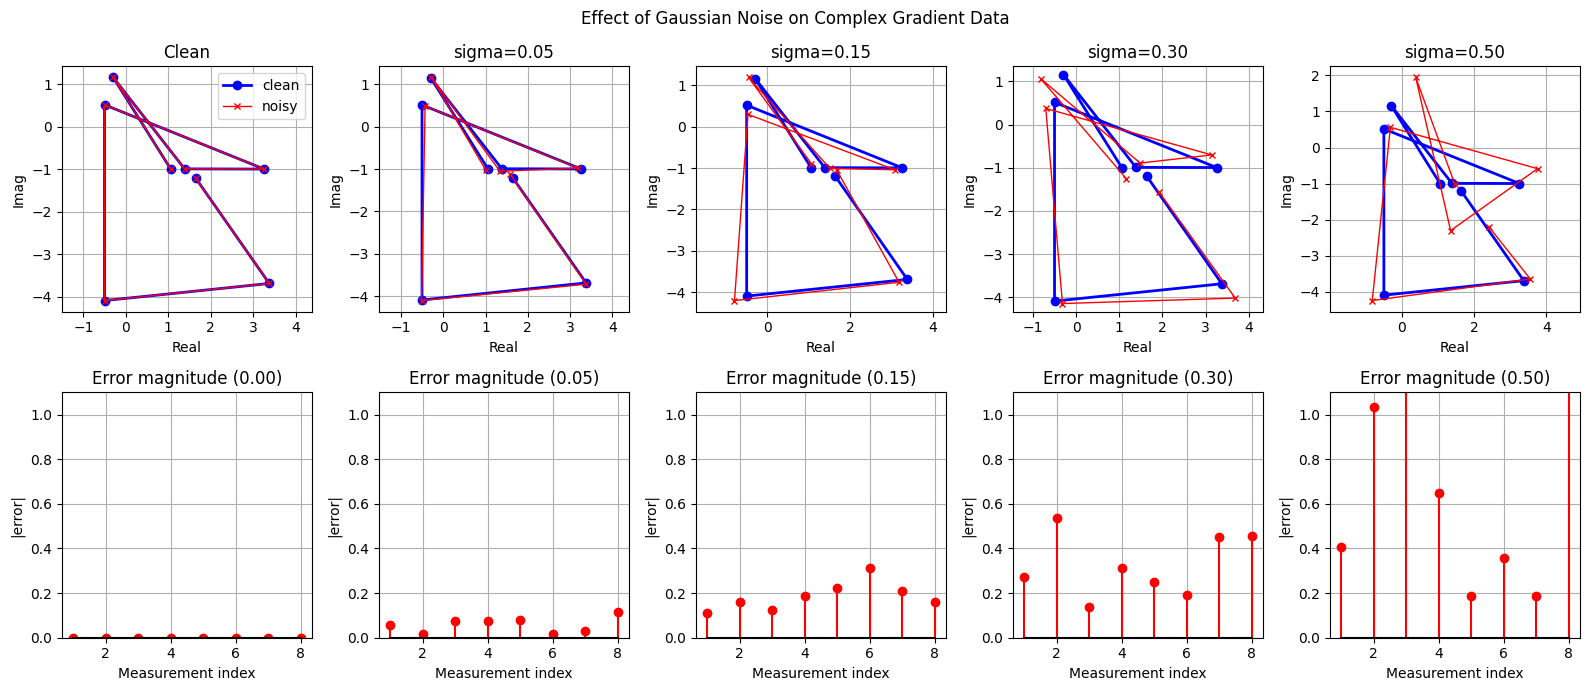

Estimated noise level from the sigma=0.30 case: 2.9119084888916147


In [4]:
N = 8
theta = np.linspace(0, 2 * np.pi, N + 1)[:-1]
measure_points = np.exp(1j * theta)
clean_grad = np.random.randn(N) + 1j * np.random.randn(N)
clean_grad = clean_grad / np.max(np.abs(clean_grad)) * 5

noise_levels = [0.0, 0.05, 0.15, 0.30, 0.50]
titles = ['Clean', 'sigma=0.05', 'sigma=0.15', 'sigma=0.30', 'sigma=0.50']

fig, axes = plt.subplots(2, len(noise_levels), figsize=(16, 7))
for i, sigma in enumerate(noise_levels):
    noisy = clean_grad if sigma == 0 else add_gaussian_noise(clean_grad, sigma)
    axes[0, i].plot(np.real(clean_grad), np.imag(clean_grad), 'bo-', linewidth=2, markersize=6, label='clean' if i == 0 else None)
    axes[0, i].plot(np.real(noisy), np.imag(noisy), 'rx-', linewidth=1, markersize=5, label='noisy' if i == 0 else None)
    axes[0, i].set_title(titles[i])
    axes[0, i].set_xlabel('Real')
    axes[0, i].set_ylabel('Imag')
    axes[0, i].axis('equal')

    error = np.zeros_like(clean_grad, dtype=float) if sigma == 0 else np.abs(clean_grad - noisy)
    axes[1, i].stem(np.arange(1, N + 1), error, linefmt='r-', markerfmt='ro', basefmt='k-')
    axes[1, i].set_title(f'Error magnitude ({sigma:.2f})')
    axes[1, i].set_xlabel('Measurement index')
    axes[1, i].set_ylabel('|error|')
    axes[1, i].set_ylim(0, 1.1 * max(1e-6, 2 * max(noise_levels)))

axes[0, 0].legend(loc='best')
fig.suptitle('Effect of Gaussian Noise on Complex Gradient Data')
fig.tight_layout()
plt.show()

print('Estimated noise level from the sigma=0.30 case:', estimate_noise_level(add_gaussian_noise(clean_grad, 0.30)))

## 5. Demo 4 setup

Here we build a small reference library of shapes and use it as the decoder stage. This is a simplified Python stand-in for the missing MATLAB reconstruction routine.

In [5]:
grid = create_grid(GridSpec(grid_size=32))
reference_library = make_reference_library(grid, seed=123, library_size=80)
print('Reference library size:', len(reference_library))
print('Grid shape:', grid.X.shape)

Reference library size: 80
Grid shape: (32, 32)


## 6. Demo 4: robustness experiment

We now vary the number of measurement points `N` and the noise level `sigma`. For each case, we measure IoU and MSE over many random shapes.

In [6]:
config = {
    'N_values': [2, 4, 6, 8],
    'sigma_levels': [0.0, 0.01, 0.02, 0.05, 0.10, 0.20, 0.50],
    'numShapes': 30,
    'gridSize': 32,
}

test_shapes = generate_test_shapes(config['numShapes'], seed=42)
results = {}

for N in config['N_values']:
    theta = np.linspace(0, 2 * np.pi, N + 1)[:-1]
    measure_points = np.exp(1j * theta)
    iou_rows = []
    mse_rows = []

    for shape in test_shapes:
        true_mask = create_domain_mask(shape, grid)
        true_coeffs = compute_coefficients(true_mask, grid.X, grid.Y, grid.dA, n_max=max(config['N_values'])).coefficients
        grad_data = compute_gradient_data(true_coeffs, measure_points, N)

        shape_iou = []
        shape_mse = []
        for sigma in config['sigma_levels']:
            noisy_grad = grad_data if sigma == 0 else add_gaussian_noise(grad_data, sigma)
            pred_mask = reconstruct_from_noisy_grad(noisy_grad, measure_points, grid, reference_library, N)
            shape_iou.append(compute_iou(pred_mask, true_mask))
            shape_mse.append(float(np.mean((pred_mask - true_mask) ** 2)))

        iou_rows.append(shape_iou)
        mse_rows.append(shape_mse)

    results[N] = {
        'iou': np.array(iou_rows),
        'mse': np.array(mse_rows),
    }

    print(f'N={N} done')

for N in config['N_values']:
    print(f'N={N} mean IoU:', np.round(results[N]['iou'].mean(axis=0), 3))
    print(f'N={N} mean MSE:', np.round(results[N]['mse'].mean(axis=0), 3))

N=2 done
N=4 done
N=6 done
N=8 done
N=2 mean IoU: [0.401 0.313 0.252 0.233 0.147 0.142 0.094]
N=2 mean MSE: [0.089 0.107 0.133 0.162 0.2   0.234 0.27 ]
N=4 mean IoU: [0.426 0.386 0.265 0.259 0.167 0.177 0.128]
N=4 mean MSE: [0.087 0.097 0.124 0.149 0.212 0.219 0.267]
N=6 mean IoU: [0.426 0.44  0.316 0.242 0.173 0.119 0.127]
N=6 mean MSE: [0.087 0.09  0.109 0.143 0.18  0.224 0.292]
N=8 mean IoU: [0.422 0.409 0.316 0.263 0.169 0.151 0.098]
N=8 mean MSE: [0.09  0.095 0.107 0.127 0.16  0.221 0.267]


## 7. Plot the experiment

These plots make the tradeoff visible: more noise hurts performance, while more measurements usually help.

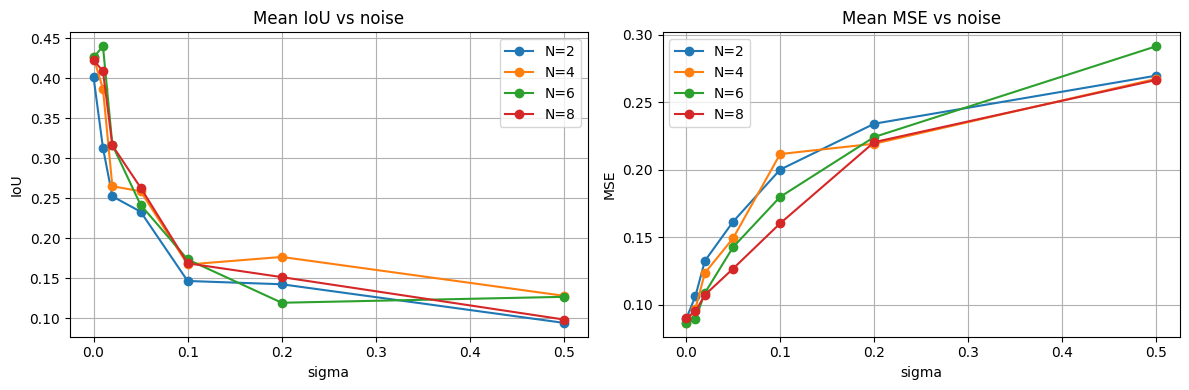

C:\Users\prest\AppData\Local\Temp\ipykernel_664552\673661543.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


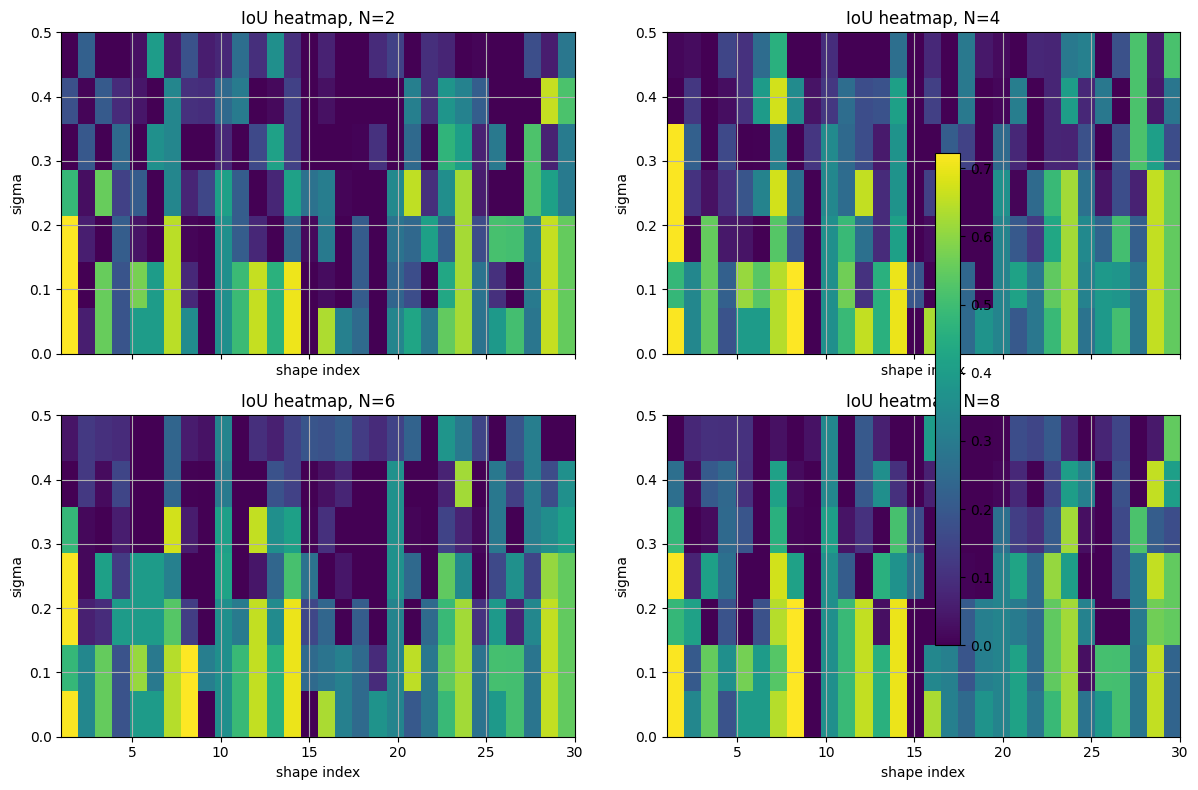

In [7]:
sigma_levels = np.array(config['sigma_levels'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for N in config['N_values']:
    axes[0].plot(sigma_levels, results[N]['iou'].mean(axis=0), marker='o', label=f'N={N}')
    axes[1].plot(sigma_levels, results[N]['mse'].mean(axis=0), marker='o', label=f'N={N}')

axes[0].set_title('Mean IoU vs noise')
axes[0].set_xlabel('sigma')
axes[0].set_ylabel('IoU')
axes[0].legend()

axes[1].set_title('Mean MSE vs noise')
axes[1].set_xlabel('sigma')
axes[1].set_ylabel('MSE')
axes[1].legend()

fig.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=False)
for ax, N in zip(axes.flat, config['N_values']):
    im = ax.imshow(results[N]['iou'].T, aspect='auto', origin='lower', cmap='viridis',
                   extent=[1, config['numShapes'], sigma_levels[0], sigma_levels[-1]])
    ax.set_title(f'IoU heatmap, N={N}')
    ax.set_xlabel('shape index')
    ax.set_ylabel('sigma')

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
fig.tight_layout()
plt.show()

## 8. Example reconstruction figure

This figure compares the ground-truth mask with reconstructions from clean data and noisy data. It is the easiest way to see how Gaussian noise changes the output.

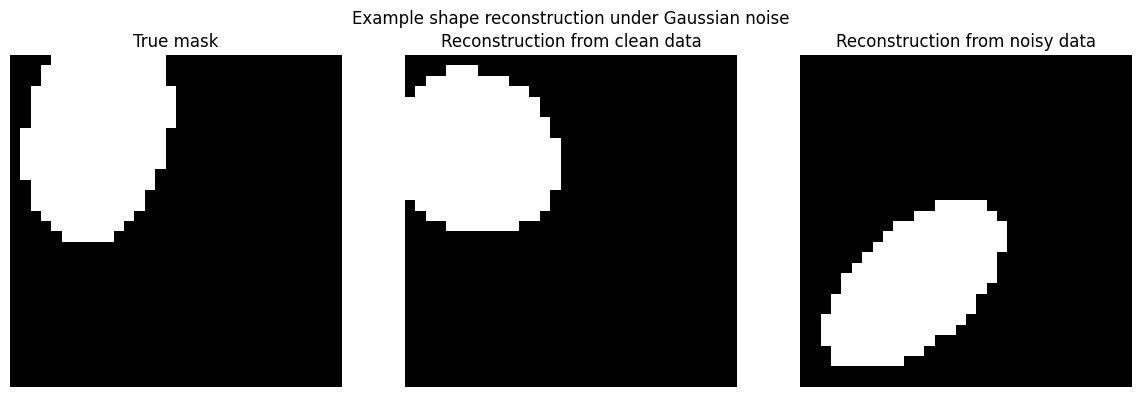

IoU clean: 0.7196652719665272
IoU noisy: 0.012594458438287154


In [8]:
example_shape = test_shapes[0]
true_mask = create_domain_mask(example_shape, grid)
n_terms = 8
theta = np.linspace(0, 2 * np.pi, n_terms + 1)[:-1]
measure_points = np.exp(1j * theta)
true_coeffs = compute_coefficients(true_mask, grid.X, grid.Y, grid.dA, n_max=n_terms).coefficients
clean_grad = compute_gradient_data(true_coeffs, measure_points, n_terms)
pred_clean = reconstruct_from_noisy_grad(clean_grad, measure_points, grid, reference_library, n_terms)
pred_noisy = reconstruct_from_noisy_grad(add_gaussian_noise(clean_grad, 0.20), measure_points, grid, reference_library, n_terms)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, mask, title in zip(axes, [true_mask, pred_clean, pred_noisy], ['True mask', 'Reconstruction from clean data', 'Reconstruction from noisy data']):
    ax.imshow(mask, cmap='gray', origin='lower')
    ax.set_title(title)
    ax.axis('off')

fig.suptitle('Example shape reconstruction under Gaussian noise')
fig.tight_layout()
plt.show()

print('IoU clean:', compute_iou(pred_clean, true_mask))
print('IoU noisy:', compute_iou(pred_noisy, true_mask))

## 9. Metrics notes

- IoU measures overlap between the predicted and true masks. Higher is better.
- MSE measures average squared pixel error. Lower is better.
- SNR compares signal power to noise power in dB. Higher is better.

Simple interpretation: if sigma goes up, SNR goes down, and reconstruction quality usually drops too.

## 10. Main takeaway

Gaussian noise makes the measurements less reliable, so the reconstruction stage has less information to work with. In practice, cleaner measurements, more sampling points, and a robust decoder all help.

Notebook note: the Task 5 PDF is about noise sensitivity, so the main pattern to remember is that higher noise means worse IoU and higher MSE unless the reconstruction method is made more robust.